# Everything, at the operating points that matter

One notebook holding the whole result set: **AUROC and TPR at 1, 5 and 10 percent
FPR**, for every operator, every position, every attack, every dataset, both
architectures.

## Why the operating point is the headline, not AUROC

AUROC summarises the whole ROC curve, including regions no deployment would ever
run in. A detector screening real traffic runs at a false positive rate the
business can absorb, which is 1 or 5 percent, not 25.

The gap between those views is large and it is not in our favour. The deployment
configuration scores **AUROC 0.826** on the CIFAR-100 1 percent panel and
**TPR 0.124 at 1 percent FPR**. Both are true. Only one of them describes what
happens if you turn it on.

The 25 percent quantile that PSBD's paper reports, and that this project inherited
as its headline, discards **a quarter of clean traffic**. That is a choice, not a
measurement: the quantile sets the false positive rate mechanically, so the only
question the number answers is how much of the backdoor falls below the same line.

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# One row per placement, rate, PSU variant and quantile. Built by
# `python -m cli.summary --operating-points`, which reads the per-rate blocks that
# already record all 6 quantiles rather than recomputing anything.
points = pd.read_csv("results/operating_points.csv")

# The rows that can be pooled: a plain measurement whose stage-1 tensors still
# exist. See notebook 12 for why this filter is not optional.
points = points[points["variant"].isna() & points["cache_backed"]]

# Adaptive-attacker checkpoints are a different question and belong in notebook 11.
# Pooling them here drags the deployment configuration from 0.826 to 0.587.
points = points[~points["folder"].str.contains("evade")]

print(f"{len(points):,} rows, {points['folder'].nunique()} checkpoints")
print(f"quantiles: {sorted(points['quantile'].unique())}")
print(f"PSU variants: {sorted(points['psu_variant'].unique())}")

632,952 rows, 163 checkpoints
quantiles: [np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25)]
PSU variants: ['absolute', 'captured_only', 'fractional']


## Reading a placement at a matched disturbance

Two placements can only be compared at a matched clean-validation shift ratio,
because the same nominal rate is a different amount of disturbance at different
sites. Everything below picks, per checkpoint, the swept rate whose validation
shift ratio lands nearest the target, and carries the achieved value so a
mismatch is visible rather than hidden.

In [2]:
TARGET_SHIFT = 0.6


def at_matched_shift(frame, target=TARGET_SHIFT):
    """Per checkpoint and quantile, the swept rate nearest the target shift ratio."""
    usable = frame.dropna(subset=["sigma_validation"]).copy()
    usable["gap"] = (usable["sigma_validation"] - target).abs()
    keys = ["folder", "placement", "psu_variant", "quantile"]
    chosen = usable.loc[usable.groupby(keys)["gap"].idxmin()]
    return chosen


def operating_table(frame, group):
    """AUROC once, TPR at each quantile, plus the achieved shift ratio."""
    matched = at_matched_shift(frame)
    wide = (
        matched.pivot_table(index=group, columns="quantile", values="tpr", aggfunc="mean")
        .rename(columns=lambda q: f"TPR@{q:.0%}FPR")
    )
    wide["AUROC"] = matched.groupby(group)["auroc"].mean()
    wide["sigma"] = matched.groupby(group)["sigma_validation"].mean()
    wide["n"] = matched.groupby(group)["folder"].nunique()
    return wide

## 1. The deployment configuration, across every attack

`token_mask` at `before_attention_norm`, fractional PSU, read at matched shift
ratio 0.6. One row per attack so the spread is visible rather than averaged away.

In [3]:
DEPLOY = "before_attention_norm_token_mask"
deploy = points[
    (points["placement"] == DEPLOY)
    & (points["psu_variant"] == "fractional")
    & (points["asr"] >= 0.5)
]
by_attack = operating_table(deploy, "attack").sort_values("AUROC", ascending=False)
by_attack.round(3)

quantile,TPR@1%FPR,TPR@5%FPR,TPR@10%FPR,TPR@15%FPR,TPR@20%FPR,TPR@25%FPR,AUROC,sigma,n
attack,,,,,,,,,
blend,0.582,0.962,0.985,0.991,0.994,0.996,0.983,0.592,15
bpp,0.524,0.890,0.953,0.965,0.971,0.976,0.968,0.623,12
lf,0.549,0.828,0.936,0.954,0.964,0.971,0.957,0.578,10
badnet_a2o,0.446,0.723,0.850,0.903,0.939,0.966,0.953,0.547,15
adaptive_blend,0.670,0.883,0.894,0.896,0.897,0.897,0.893,0.610,12
lc,0.239,0.425,0.523,0.595,0.667,0.732,0.805,0.593,9
sig,0.457,0.575,0.623,0.650,0.673,0.690,0.778,0.571,2
wanet,0.071,0.302,0.430,0.529,0.610,0.676,0.767,0.540,10
badnet_a2a,0.010,0.019,0.033,0.053,0.080,0.112,0.384,0.583,9


The `TPR@1%FPR` column is the one to read first. An attack with AUROC above 0.9
and TPR near 0 at 1 percent FPR is not detectable in deployment, it is only
separable in principle.

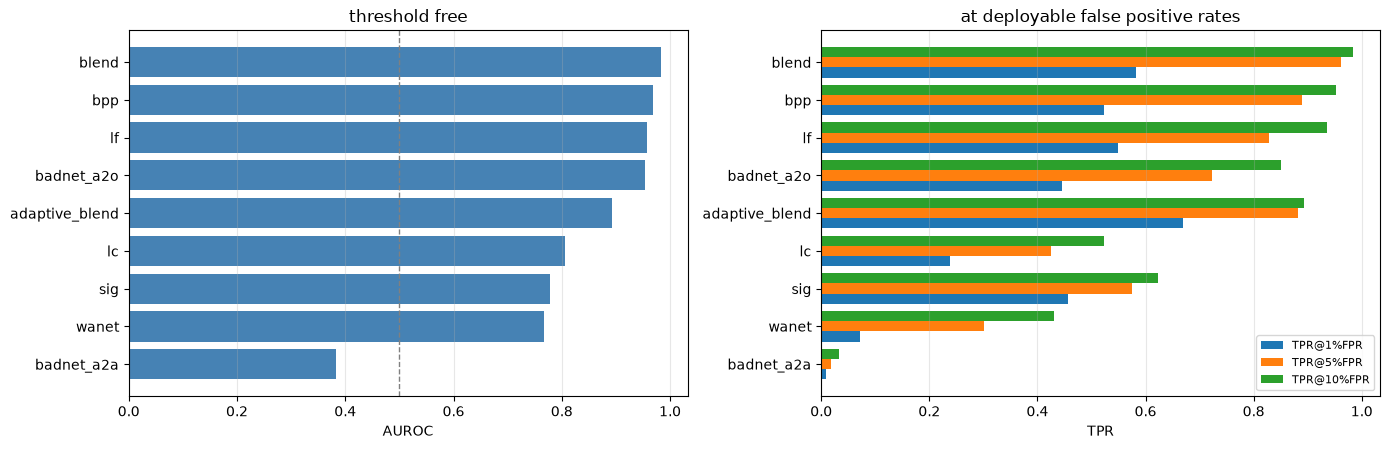

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ordered = by_attack.sort_values("AUROC")
positions = np.arange(len(ordered))

axes[0].barh(positions, ordered["AUROC"], color="steelblue")
axes[0].axvline(0.5, ls="--", lw=1, c="grey")
axes[0].set_yticks(positions); axes[0].set_yticklabels(ordered.index)
axes[0].set_xlabel("AUROC"); axes[0].set_title("threshold free")

width = 0.27
for offset, quantile in zip((-width, 0, width), (0.01, 0.05, 0.10)):
    column = f"TPR@{quantile:.0%}FPR"
    axes[1].barh(positions + offset, ordered[column], height=width, label=column)
axes[1].set_yticks(positions); axes[1].set_yticklabels(ordered.index)
axes[1].set_xlabel("TPR"); axes[1].set_title("at deployable false positive rates")
axes[1].legend(fontsize=8)
for axis in axes:
    axis.grid(alpha=0.3, axis="x")
figure.tight_layout()
plt.show()

## 2. Every operator, at every position

The full grid. `n` is how many checkpoints contributed, and a small `n` is a
reason to distrust a row rather than to quote it.

In [5]:
grid = points[(points["psu_variant"] == "fractional") & (points["asr"] >= 0.5)]
full = operating_table(grid, ["position", "operator"])
full = full[full["n"] >= 8].sort_values("AUROC", ascending=False)
pd.set_option("display.max_rows", 60)
full.round(3)

,quantile,TPR@1%FPR,TPR@5%FPR,TPR@10%FPR,TPR@15%FPR,TPR@20%FPR,TPR@25%FPR,AUROC,sigma,n
position,operator,,,,,,,,,
both_sublayer_inputs,token_mask,0.347,0.616,0.712,0.789,0.840,0.871,0.886,0.648,48
before_attention,gaussian,0.498,0.691,0.768,0.802,0.826,0.844,0.886,0.628,9
mlp_neurons,gaussian,0.307,0.558,0.678,0.744,0.784,0.811,0.866,0.767,9
before_attention_norm,token_mask,0.416,0.670,0.740,0.774,0.800,0.823,0.860,0.583,94
before_attention,dropout,0.341,0.590,0.651,0.701,0.737,0.770,0.842,0.669,31
post_residual,channel_mask,0.517,0.635,0.694,0.729,0.755,0.776,0.837,0.731,68
before_mlp_residual,dropout,0.246,0.507,0.638,0.698,0.738,0.770,0.825,0.595,121
pre_residual,channel_mask,0.287,0.515,0.623,0.687,0.737,0.772,0.824,0.649,64
before_mlp,gaussian,0.148,0.485,0.641,0.711,0.739,0.759,0.820,0.506,30


## 3. Where a probe must not go

Three separate failure modes, and they are not interchangeable.

**Inert by construction.** `token_mask` after the final norm cannot reach anything
the classifier reads, because ViT's head reads token 0 alone and `token_mask`
protects token 0. PSU would be identically 0 and AUROC exactly 0.5, which reads as
"this position does not matter" rather than "this probe never fired".
`psbd.operators.check_operator_position` refuses it.

**Wrong axis.** `input_pixels` carries a `(batch, channels, height, width)` image,
and the token operators read a rank-4 tensor as Swin's
`(batch, height, width, channels)`. `token_mask` there masks image rows
independently per colour channel. It runs, and it answers a different question.

**No information left to find.** A probe at the classifier head is the confidence
null. The closed form for the Hessian trace of the predicted class probability
depends on nothing but the softmax vector, so a probe there can carry nothing that
free max-softmax confidence does not already have. Measured, the two agree to
within 0.003.

In [6]:
from psbd.operators import check_operator_position

for operator, position in (
    ("token_mask", "final_norm_out"),
    ("token_mask", "input_pixels"),
    ("channel_mask", "input_pixels"),
    ("head_mask", "before_mlp"),
    ("token_mask", "before_attention_norm"),
):
    try:
        check_operator_position(operator, position)
        print(f"  ALLOWED  {operator:13s} @ {position}")
    except ValueError as error:
        print(f"  REFUSED  {operator:13s} @ {position}\n           {str(error)[:96]}...")

  REFUSED  token_mask    @ final_norm_out
           token_mask at final_norm_out: final_norm_out sits after the final LayerNorm, and ViT's head read...
  REFUSED  token_mask    @ input_pixels
           token_mask at input_pixels: input_pixels carries a (batch, channels, height, width) image, and t...
  REFUSED  channel_mask  @ input_pixels
           channel_mask at input_pixels: input_pixels carries a (batch, channels, height, width) image, and...
  REFUSED  head_mask     @ before_mlp
           head_mask is only meaningful at ('attention_heads',), not at 'before_mlp'...
  ALLOWED  token_mask    @ before_attention_norm


In [7]:
# The head position, measured rather than argued. gain_scale is the only operator
# swept there, so the comparison is against the confidence null on the same cells.
head = points[(points["position"] == "final_norm_out") & (points["psu_variant"] == "fractional")]
if len(head):
    print(operating_table(head, "operator").round(3).to_string())
    print()
    print("A probe here scores at or below chance. Notebook 12 and audit A18 show")
    print("why: at the logits the statistic is a function of the softmax vector")
    print("alone, so it cannot beat the free confidence baseline it reduces to.")
else:
    print("no cache-backed rows at final_norm_out in the filtered set")

quantile    TPR@1%FPR  TPR@5%FPR  TPR@10%FPR  TPR@15%FPR  TPR@20%FPR  TPR@25%FPR  AUROC  sigma    n
operator                                                                                           
gain_scale      0.005      0.041       0.098       0.149       0.197       0.239   0.44  0.001  101

A probe here scores at or below chance. Notebook 12 and audit A18 show
why: at the logits the statistic is a function of the softmax vector
alone, so it cannot beat the free confidence baseline it reduces to.


## 4. Depth: one band of layers, or all of them

Everything above perturbs a position in **every** block. The depth-band sweep asks
a different question: what if the probe is restricted to a contiguous span?

This matters because where a trigger's signal reaches the residual stream is
attack-dependent. A patch trigger and a blended trigger do not crystallize at the
same depth, so perturbing all 12 blocks cannot distinguish "this position matters"
from "this depth matters". Those are different claims.

The bands are restrictions of `pre_residual`, so `pre_residual` itself is the
all-blocks control and the comparison is like for like.

In [8]:
depth_source = pd.read_csv("results/operating_points.csv")
depth_source = depth_source[
    depth_source["cache_backed"]
    & (~depth_source["folder"].str.contains("evade"))
    & (depth_source["psu_variant"] == "fractional")
    & (depth_source["asr"] >= 0.5)
    & (depth_source["position"] == "pre_residual")
]

# The all-blocks control is the plain placement; the bands carry a variant tag.
depth_source["band"] = depth_source["variant"].fillna("all blocks")
vit_depth = depth_source[depth_source["architecture"] == "vit"]

BAND_ORDER = ["blocks_1_4", "blocks_5_8", "blocks_9_12", "all blocks"]
depth = operating_table(vit_depth, "band")
depth = depth.reindex([b for b in BAND_ORDER if b in depth.index])
depth.round(3)

quantile,TPR@1%FPR,TPR@5%FPR,TPR@10%FPR,TPR@15%FPR,TPR@20%FPR,TPR@25%FPR,AUROC,sigma,n
band,,,,,,,,,
blocks_1_4,0.150,0.334,0.443,0.536,0.619,0.669,0.771,0.588,76
blocks_5_8,0.380,0.664,0.751,0.798,0.826,0.844,0.866,0.565,76
blocks_9_12,0.623,0.701,0.740,0.768,0.788,0.806,0.852,0.415,76
all blocks,0.207,0.399,0.506,0.583,0.644,0.691,0.781,0.635,92


Read the `n` column before the rest. Then read down the `AUROC` column against the
`all blocks` row, which is the control.

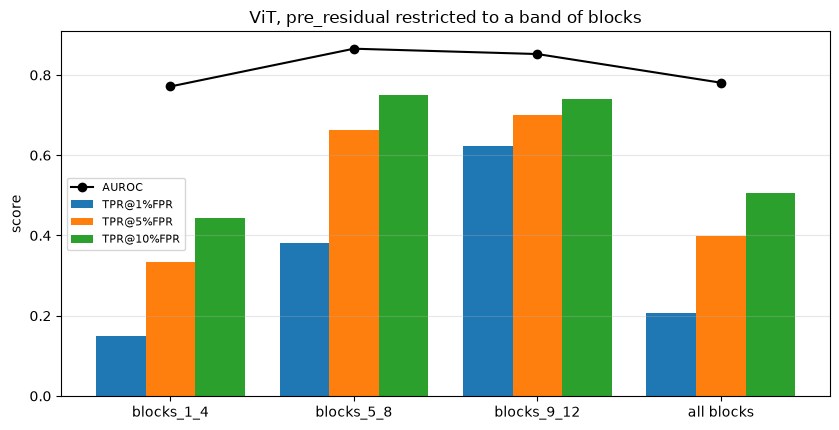

In [9]:
figure, axis = plt.subplots(figsize=(8.5, 4.4))
present = [b for b in BAND_ORDER if b in depth.index]
positions = np.arange(len(present))
width = 0.27
for offset, quantile in zip((-width, 0, width), (0.01, 0.05, 0.10)):
    axis.bar(positions + offset, depth.loc[present, f"TPR@{quantile:.0%}FPR"],
             width=width, label=f"TPR@{quantile:.0%}FPR")
axis.plot(positions, depth.loc[present, "AUROC"], marker="o", color="black", label="AUROC")
axis.set_xticks(positions); axis.set_xticklabels(present)
axis.set_ylabel("score"); axis.set_title("ViT, pre_residual restricted to a band of blocks")
axis.legend(fontsize=8); axis.grid(alpha=0.3, axis="y")
figure.tight_layout()
plt.show()

### Does the best band depend on the attack?

This is the question that decides whether depth is a tuning knob or a property of
the trigger. If different attacks peak in different bands, a single deployed depth
is a compromise and the paper has to say so.

In [10]:
per_attack_band = operating_table(vit_depth, ["attack", "band"])
per_attack_band = per_attack_band[per_attack_band["n"] >= 2]

auroc_grid = (
    per_attack_band["AUROC"]
    .unstack("band")
    .reindex(columns=[b for b in BAND_ORDER if b in per_attack_band.index.get_level_values("band")])
)
auroc_grid["best band"] = auroc_grid.idxmax(axis=1)
auroc_grid["best minus all blocks"] = (
    auroc_grid.drop(columns=["best band"]).max(axis=1) - auroc_grid["all blocks"]
)
auroc_grid.round(3)

band,blocks_1_4,blocks_5_8,blocks_9_12,all blocks,best band,best minus all blocks
attack,,,,,,
adaptive_blend,0.795,0.910,0.864,0.806,blocks_5_8,0.104
badnet_a2a,0.384,0.246,0.146,0.327,blocks_1_4,0.057
badnet_a2o,0.773,0.897,0.786,0.827,blocks_5_8,0.071
blend,0.878,0.911,0.983,0.877,blocks_9_12,0.106
bpp,0.874,0.944,0.968,0.878,blocks_9_12,0.090
lc,0.624,0.816,0.640,0.621,blocks_5_8,0.195
lf,0.810,0.938,0.975,0.872,blocks_9_12,0.103
sig,NaN,NaN,NaN,0.729,all blocks,0.000
wanet,0.558,0.931,0.960,0.758,blocks_9_12,0.202


In [11]:
best_counts = auroc_grid["best band"].value_counts()
print("which band wins, counted over attacks:")
print(best_counts.to_string())
print()
gains = auroc_grid["best minus all blocks"]
print(f"attacks where a single band beats all-blocks: {(gains > 0.01).sum()} of {len(gains)}")
print(f"median gain from choosing the best band: {gains.median():+.3f}")
print(f"largest gain: {gains.max():+.3f} on {gains.idxmax()}")
print(f"largest loss: {gains.min():+.3f} on {gains.idxmin()}")

which band wins, counted over attacks:
best band
blocks_9_12    4
blocks_5_8     3
blocks_1_4     1
all blocks     1

attacks where a single band beats all-blocks: 8 of 9
median gain from choosing the best band: +0.103
largest gain: +0.202 on wanet
largest loss: +0.000 on sig


### What restricting the probe costs

A band perturbs fewer blocks, so at the same nominal rate it delivers less total
disturbance. If the bands are read at a lower shift ratio than the all-blocks
control, part of any difference is strength rather than depth, which is the
confound that sank the old headline. The `sigma` column above is what makes that
checkable.

In [12]:
strength = depth[["sigma", "AUROC", "n"]].copy()
strength["sigma minus all blocks"] = strength["sigma"] - depth.loc["all blocks", "sigma"]
print(strength.round(3).to_string())
print()
worst = strength["sigma minus all blocks"].abs().max()
print(f"largest strength mismatch against the control: {worst:.3f}")
print(
    "Under about 0.05 the bands are genuinely comparable to all-blocks. Above it,\n"
    "part of the difference is how hard each was hit and the comparison is not clean."
)

quantile     sigma  AUROC   n  sigma minus all blocks
band                                                 
blocks_1_4   0.588  0.771  76                  -0.047
blocks_5_8   0.565  0.866  76                  -0.070
blocks_9_12  0.415  0.852  76                  -0.220
all blocks   0.635  0.781  92                   0.000

largest strength mismatch against the control: 0.220
Under about 0.05 the bands are genuinely comparable to all-blocks. Above it,
part of the difference is how hard each was hit and the comparison is not clean.


## 5. Which PSU variant to report

Three are recorded. They answer different questions and should not be mixed inside
one table.

- **absolute** is the paper's form, a raw drop in confidence.
- **fractional** divides by the starting confidence, which removes the objection
  that PSU is really measuring how confident a prediction began.
- **captured only** restricts **both** splits to the images the trigger actually
  flipped. A triggered image the model still classifies correctly is behaviourally
  clean, so scoring it as a detection positive charges the detector for the
  attack's failure. Both sides must be restricted; restricting only the backdoor
  side compares hard images against easy ones and reported 0.921 for a benign
  control that scores 0.505 when done correctly.

In [13]:
variants = points[(points["placement"] == DEPLOY) & (points["asr"] >= 0.5)]
by_variant = operating_table(variants, "psu_variant")
by_variant.round(3)

quantile,TPR@1%FPR,TPR@5%FPR,TPR@10%FPR,TPR@15%FPR,TPR@20%FPR,TPR@25%FPR,AUROC,sigma,n
psu_variant,,,,,,,,,
absolute,0.416,0.669,0.739,0.771,0.798,0.821,0.872,0.583,94
captured_only,0.434,0.698,0.772,0.805,0.831,0.852,0.894,0.583,94
fractional,0.416,0.670,0.740,0.774,0.800,0.823,0.860,0.583,94


## 6. Coverage, before any of the above is averaged

An average over an unequal grid is not the number it appears to be, and this
project has had conclusions inverted by exactly that. Swin has no GTSRB rows here:
40 checkpoints are trained and were never swept, and that sweep is running.

In [14]:
coverage = (
    points.groupby(["architecture", "dataset"])
    .agg(checkpoints=("folder", "nunique"), placements=("placement", "nunique"))
    .reset_index()
)
print(coverage.to_string(index=False))
print()
print("Any mean over datasets currently averages 4 for vit and 3 for swin.")

architecture  dataset  checkpoints  placements
        swin  cifar10           25           7
        swin cifar100           27           9
         vit  cifar10           40          51
         vit cifar100           27          39
         vit    gtsrb           22          36
         vit     tiny           22          36

Any mean over datasets currently averages 4 for vit and 3 for swin.


## What to take away

**Report the operating point, not just AUROC.** The deployment configuration is
AUROC 0.826 and TPR 0.124 at 1 percent FPR on the CIFAR-100 1 percent panel. A
reader given only the first number would form the wrong impression of what
happens when it is switched on.

**The 25 percent quantile is a choice about clean loss, not a result.** It fixes
the false positive rate mechanically. The only thing it measures is how much
backdoor falls below the same line.

**Three places a probe must not go**, for three different reasons: inert by
construction at the final norm, wrong axis at the input pixels, and no information
left to find at the classifier head, where the statistic reduces to free
confidence.

**Depth is attack-dependent**, so a single deployed band is a compromise. The
tables above say by how much, and the strength check says whether the comparison
was clean.